/Users/bindhu/Desktop/DL_AI_Intership/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.55k/1.55k [00:00<00:00, 1.47MB/s]

Extracting files...


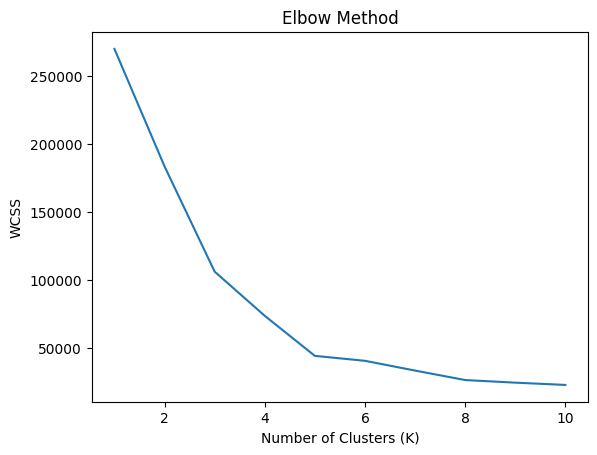

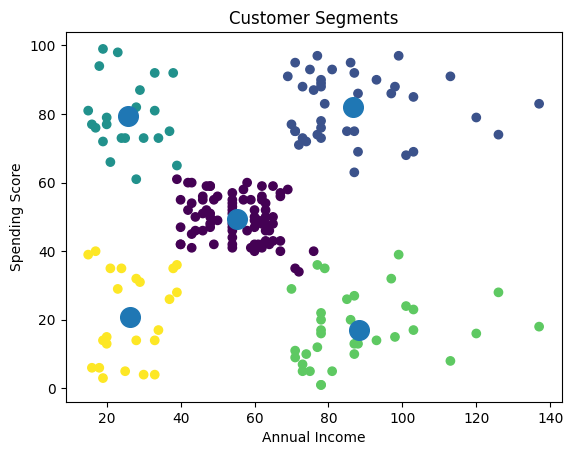

In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Download dataset
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

# Load dataset
df = pd.read_csv(path + "/Mall_Customers.csv")

# Select required features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# -------------------------------
# Elbow Method
# -------------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow graph
plt.figure()
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# -------------------------------
# Apply K-Means (choose K from graph, usually 5)
# -------------------------------
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# -------------------------------
# Visualize Clusters
# -------------------------------
plt.figure()
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_kmeans)

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()